Multiple Linear Regression:

👉 English:
Multiple Linear Regression is used to predict one output (Y) using two or more inputs (X₁, X₂, …)

👉 বাংলা:
Multiple Linear Regression হলো এমন একটি পদ্ধতি যেখানে একটি আউটপুট (Y) কে একাধিক ইনপুট (X₁, X₂, …) দিয়ে predict করা হয়

Why use it?

👉 English:
Real-world problems depend on multiple factors

In [3]:
from sklearn.linear_model import LinearRegression

# দুইটা feature
X = [[1000, 2], [1500, 3], [2000, 4]]  # size, rooms
y = [200, 300, 400]  # price

model = LinearRegression()
model.fit(X, y)

# prediction
print(model.predict([[1200, 3]]))

[240.00024]


Getting Started with Multiple Linear Regression

#importing libraries

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error

import math

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import math

DataFraming

In [26]:
df = pd.read_csv("50_Startups.csv")

df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


Graph

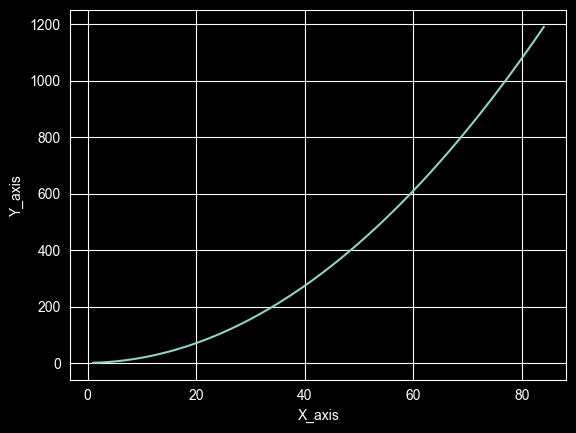

In [27]:
plt.plot(X,y)
plt.xlabel("X_axis")
plt.ylabel("Y_axis")
plt.show()

In [8]:
X = df[["R&D Spend", "Administration", "Marketing Spend", "State"]].values
#.values is converting dataframe into array
print(X)
y = df[["Profit"]].values
print(y)

[[165349.2 136897.8 471784.1 'New York']
 [162597.7 151377.59 443898.53 'California']
 [153441.51 101145.55 407934.54 'Florida']
 [144372.41 118671.85 383199.62 'New York']
 [142107.34 91391.77 366168.42 'Florida']
 [131876.9 99814.71 362861.36 'New York']
 [134615.46 147198.87 127716.82 'California']
 [130298.13 145530.06 323876.68 'Florida']
 [120542.52 148718.95 311613.29 'New York']
 [123334.88 108679.17 304981.62 'California']
 [101913.08 110594.11 229160.95 'Florida']
 [100671.96 91790.61 249744.55 'California']
 [93863.75 127320.38 249839.44 'Florida']
 [91992.39 135495.07 252664.93 'California']
 [119943.24 156547.42 256512.92 'Florida']
 [114523.61 122616.84 261776.23 'New York']
 [78013.11 121597.55 264346.06 'California']
 [94657.16 145077.58 282574.31 'New York']
 [91749.16 114175.79 294919.57 'Florida']
 [86419.7 153514.11 0.0 'New York']
 [76253.86 113867.3 298664.47 'California']
 [78389.47 153773.43 299737.29 'New York']
 [73994.56 122782.75 303319.26 'Florida']
 [67532

Preprocessing

Coverting Text variables to Numbers

remainder='passthrough'

👉 English:
Keep other columns unchanged

👉 বাংলা:
বাকি column আগের মতো রাখে

In [9]:
st = ColumnTransformer([("State", OneHotEncoder(), [3])], remainder = 'passthrough')
X = st.fit_transform(X)
print(X)

[[0.0 0.0 1.0 165349.2 136897.8 471784.1]
 [1.0 0.0 0.0 162597.7 151377.59 443898.53]
 [0.0 1.0 0.0 153441.51 101145.55 407934.54]
 [0.0 0.0 1.0 144372.41 118671.85 383199.62]
 [0.0 1.0 0.0 142107.34 91391.77 366168.42]
 [0.0 0.0 1.0 131876.9 99814.71 362861.36]
 [1.0 0.0 0.0 134615.46 147198.87 127716.82]
 [0.0 1.0 0.0 130298.13 145530.06 323876.68]
 [0.0 0.0 1.0 120542.52 148718.95 311613.29]
 [1.0 0.0 0.0 123334.88 108679.17 304981.62]
 [0.0 1.0 0.0 101913.08 110594.11 229160.95]
 [1.0 0.0 0.0 100671.96 91790.61 249744.55]
 [0.0 1.0 0.0 93863.75 127320.38 249839.44]
 [1.0 0.0 0.0 91992.39 135495.07 252664.93]
 [0.0 1.0 0.0 119943.24 156547.42 256512.92]
 [0.0 0.0 1.0 114523.61 122616.84 261776.23]
 [1.0 0.0 0.0 78013.11 121597.55 264346.06]
 [0.0 0.0 1.0 94657.16 145077.58 282574.31]
 [0.0 1.0 0.0 91749.16 114175.79 294919.57]
 [0.0 0.0 1.0 86419.7 153514.11 0.0]
 [1.0 0.0 0.0 76253.86 113867.3 298664.47]
 [0.0 0.0 1.0 78389.47 153773.43 299737.29]
 [0.0 1.0 0.0 73994.56 122782.75 3

Splitting Dataset

test_size=0.2

👉 English:
20% data → test
80% data → train

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)


Training the Model

👉 English:
Training means teaching the model to learn the relationship between X (input) and y (output)


🔹 Code (Training Step)
model = LinearRegression()

model.fit(X_train, y_train)

🔹 Step-by-Step
1️⃣ Model তৈরি

model = LinearRegression()

👉 English: Create model
👉 বাংলা: মডেল বানানো

2️⃣ Training
model.fit(X_train, y_train)

👉 English:
Model learns from training data

👉 বাংলা:
মডেল training data থেকে শেখে

🔹 What happens inside? 🔥

👉 Model এই equation শিখে:

𝑦=𝛼+𝛽1𝑥1+𝛽2𝑥2+⋯


👉 English:
Finds best α, β values

👉 বাংলা:
সঠিক α, β বের করে

🔹 After Training

👉 Model এখন জানে:

input → output relation

👉 এখন predict করতে পারবে ✅

🔹 Example

👉 Before training:

Model knows nothing ❌

👉 After training:

Model understands pattern ✅

In [11]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Prediction

In [12]:
y_pred = model.predict(X_test)

In [13]:
print('- y_pred : ')
print(y_pred)
print('- y_test : ')
print(y_test)

- y_pred : 
[[103015.20159796]
 [132582.27760815]
 [132447.73845174]
 [ 71976.09851258]
 [178537.48221056]
 [116161.24230167]
 [ 67851.69209676]
 [ 98791.73374687]
 [113969.43533014]
 [167921.06569551]]
- y_test : 
[[103282.38]
 [144259.4 ]
 [146121.95]
 [ 77798.83]
 [191050.39]
 [105008.31]
 [ 81229.06]
 [ 97483.56]
 [110352.25]
 [166187.94]]


Error and Accuracy

In [14]:

print(y_pred.sum().mean())
print(y_test.sum().mean())

print("So called Accuracy ", y_pred.sum().mean()/y_test.sum().mean())

1183253.9675519404
1222774.07
So called Accuracy  0.9676799636027122


In [15]:
y_pred/y_test

array([[0.99741313],
       [0.91905469],
       [0.90641918],
       [0.92515657],
       [0.93450467],
       [1.10621   ],
       [0.83531303],
       [1.01341943],
       [1.03277854],
       [1.01042871]])

Multiple Linear Regression — Steps + Library + Syntax

🔹 1️⃣ Data Collection

👉 Library: Pandas

pd.read_csv("data.csv")

🔹 2️⃣ Data Preparation (X & y)

👉 Library: Pandas

X = df[["col1","col2"]].values
y = df[["target"]].values

👉 বাংলা: input/output আলাদা করা

🔹 3️⃣ Encoding (Categorical Data)

👉 Library:

scikit-learn (OneHotEncoder, ColumnTransformer)
ColumnTransformer([("col", OneHotEncoder(), [index])], remainder='passthrough')

👉 বাংলা: text → number

🔹 4️⃣ Split Data

👉 Library: scikit-learn

train_test_split(X, y, test_size=0.2)

👉 বাংলা: train + test ভাগ

🔹 5️⃣ Train Model

👉 Library: scikit-learn (LinearRegression)

model = LinearRegression()
model.fit(X_train, y_train)

👉 বাংলা: মডেল শেখানো

🔹 6️⃣ Prediction

👉 Library: scikit-learn

model.predict(X_test)

👉 বাংলা: ফল বের করা

🔹 7️⃣ Evaluation

👉 Library: scikit-learn (metrics)

mean_squared_error(y_test, y_pred)

👉 বাংলা: error মাপা

🔹 8️⃣ Optional (Graph)

👉 Library: Matplotlib

plt.scatter(x, y)

👉 বাংলা: graph দেখা

📌 Full Flow (Super Short)

👉 English:
Pandas → sklearn → Model → Predict → Evaluate

🧠 Final Idea

👉 English:
Each step uses a specific library in ML pipeline

👉 বাংলা:
প্রতিটি step-এ আলাদা library কাজ করে 😄

Polynomial Regression

What is Polynomial Regression?

👉 English:
Polynomial Regression is used when the relationship between X and Y is not a straight line (curved)

👉 বাংলা:
Polynomial Regression তখন ব্যবহার হয় যখন X আর Y-এর সম্পর্ক straight line না হয়ে curve হয়

🔹 Idea

👉 English:
Instead of straight line → we use curve

👉 বাংলা:
সোজা লাইন না → বাঁকা (curve) লাইন ব্যবহার করা হয়

🔹 Formula
𝑦=𝑎+𝑏1𝑥+𝑏2𝑥2+𝑏3𝑥3+⋯

🔹 Meaning

👉 English:
We add powers of x (x², x³…)

👉 বাংলা:
x-এর power যোগ করা হয় (x², x³…)

🔹 Example

👉 Data:

x	y
1	1
2	4
3	9

👉 Relation:

y = x²

👉 এটা linear না → polynomial ✅

🔹 When to use?

👉 English:

Data is curved
Linear model not fitting

👉 বাংলা:

ডেটা curve আকারে
linear model ঠিক কাজ করছে না

In [19]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# data
X = np.array([1, 2, 3, 4]).reshape(-1,1)
y = np.array([1, 4, 9, 16])

# polynomial feature
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# model
model = LinearRegression()
model.fit(X_poly, y)

# prediction
y_pred = model.predict(X_poly)
print(y_pred)

[ 1.  4.  9. 16.]


Getting Started with Polynomial Regression

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import PolynomialFeatures

from sklearn.model_selection import train_test_split

import math

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
import math

DataFraming

In [22]:
dataset=pd.read_csv("Drugs_Performance.csv")
dataset.head()

,Age,Drugs_Perf
0,1,1.166667
1,2,1.833333
2,3,2.833333
3,4,4.166667
4,5,5.833333


Sepreate Data in 2 Variable

In [23]:
X = dataset[["Age"]].values
y = dataset[["Drugs_Perf"]].values
print(X)
print(y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]
 [12]
 [13]
 [14]
 [15]
 [16]
 [17]
 [18]
 [19]
 [20]
 [21]
 [22]
 [23]
 [24]
 [25]
 [26]
 [27]
 [28]
 [29]
 [30]
 [31]
 [32]
 [33]
 [34]
 [35]
 [36]
 [37]
 [38]
 [39]
 [40]
 [41]
 [42]
 [43]
 [44]
 [45]
 [46]
 [47]
 [48]
 [49]
 [50]
 [51]
 [52]
 [53]
 [54]
 [55]
 [56]
 [57]
 [58]
 [59]
 [60]
 [61]
 [62]
 [63]
 [64]
 [65]
 [66]
 [67]
 [68]
 [69]
 [70]
 [71]
 [72]
 [73]
 [74]
 [75]
 [76]
 [77]
 [78]
 [79]
 [80]
 [81]
 [82]
 [83]
 [84]]
[[1.16666667e+00]
 [1.83333333e+00]
 [2.83333333e+00]
 [4.16666667e+00]
 [5.83333333e+00]
 [7.83333333e+00]
 [1.01666667e+01]
 [1.28333333e+01]
 [1.58333333e+01]
 [1.91666667e+01]
 [2.28333333e+01]
 [2.68333333e+01]
 [3.11666667e+01]
 [3.58333333e+01]
 [4.08333333e+01]
 [4.61666667e+01]
 [5.18333333e+01]
 [5.78333333e+01]
 [6.41666667e+01]
 [7.08333333e+01]
 [7.78333333e+01]
 [8.51666667e+01]
 [9.28333333e+01]
 [1.00833333e+02]
 [1.09166667e+02]
 [1.17833333e+02]
 [1.26833333e+02]
 [1.36166

Graph

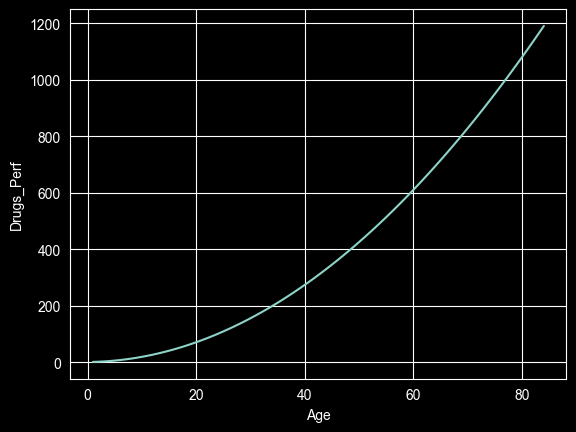

In [28]:
plt.plot(X,y)
plt.xlabel("Age")
plt.ylabel("Drugs_Perf")
plt.show()

Splitting Data: Training and Test Set

In [59]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size=0.3)

Preprocessing: Polynomial Features

In [60]:
poly = PolynomialFeatures(degree = 2)
X_poly = poly.fit_transform(X_train)
poly.fit(X_poly, Y_train)

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


Training the Model

In [61]:
model = LinearRegression()
model.fit(X_poly,Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Visualization

Text(0, 0.5, 'Drugs Performance')

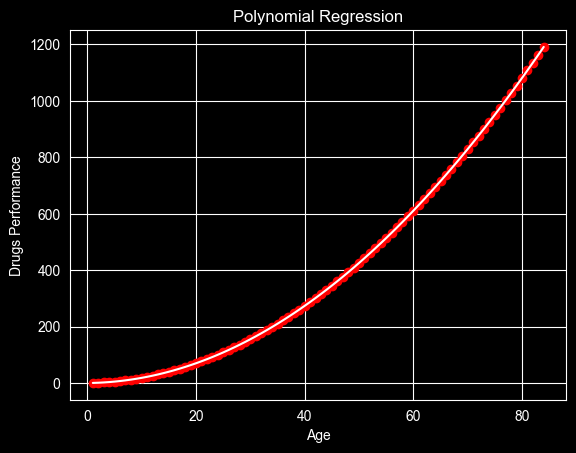

In [62]:
plt.scatter(X,y, color = 'red')
plt.plot(X,model.predict(poly.fit_transform(X)), color = 'white')
plt.title('Polynomial Regression')
plt.xlabel('Age')
plt.ylabel('Drugs Performance')

Prediction

In [63]:
print('Prediction by the model:\t', model.predict(poly.fit_transform(X_test)))

Prediction by the model:	 [[  51.83333333]
 [ 495.83333333]
 [1001.83333329]
 [ 925.8333333 ]
 [  92.83333334]
 [ 301.83333333]
 [1027.83333329]
 [ 876.8333333 ]
 [ 392.83333333]
 [ 551.83333332]
 [ 345.83333333]
 [   5.83333333]
 [ 425.83333333]
 [ 631.16666665]
 [ 274.16666667]
 [  22.83333333]
 [1162.83333328]
 [ 829.16666664]
 [ 409.16666666]
 [ 235.16666667]
 [ 210.83333334]
 [ 155.83333334]
 [ 260.83333333]
 [ 126.83333334]
 [ 247.83333334]
 [   7.83333333]]


In [66]:
X_train_poly = poly.fit_transform(X_train)
model.fit(X_train_poly, Y_train)

X_test_poly = poly.transform(X_test)
y_pred = model.predict(X_test_poly)

print(mean_squared_error(Y_test, y_pred))
print(r2_score(Y_test, y_pred))

1.0513045225768294e-14


NameError: name 'r2_score' is not defined